# Task 1: Exploratory Data Analysis and Data Preprocessing

**Objective:** Understand the structure and quality of the CFPB complaint dataset and prepare it for the RAG pipeline.

### Steps
1. Load the raw dataset
2. EDA — distributions, narrative lengths, missing data
3. Filter to four target products
4. Clean narrative text
5. Save `data/processed/filtered_complaints.csv`

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_processor import clean_narrative

sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Load Dataset

In [2]:
RAW_PATH = '../data/raw/complaints.csv'
import polars as pl

df_raw = pl.scan_csv(RAW_PATH )


In [3]:

row_count =df_raw.select(pl.len()).collect()

print(row_count)

shape: (1, 1)
┌─────────┐
│ len     │
│ ---     │
│ u32     │
╞═════════╡
│ 9609797 │
└─────────┘


#### To show the first five records of the Complients dataset

In [11]:
print(
    df_raw.select([
        "Product",
        "Consumer complaint narrative"
    ])
    .head(5)
    .collect()
)

shape: (5, 2)
┌─────────────────────────────────┬──────────────────────────────┐
│ Product                         ┆ Consumer complaint narrative │
│ ---                             ┆ ---                          │
│ str                             ┆ str                          │
╞═════════════════════════════════╪══════════════════════════════╡
│ Credit reporting or other pers… ┆ null                         │
│ Debt collection                 ┆ null                         │
│ Credit reporting or other pers… ┆ null                         │
│ Credit reporting or other pers… ┆ null                         │
│ Credit reporting or other pers… ┆ null                         │
└─────────────────────────────────┴──────────────────────────────┘


#### Interpritation
##### Unfortunatelly The result feated is having null narratives, and it's normal.

In [4]:
products = (
    df_raw.select("Product")
    .unique()
    .sort("Product")
    .collect()
)
print(products)

shape: (21, 1)
┌─────────────────────────────────┐
│ Product                         │
│ ---                             │
│ str                             │
╞═════════════════════════════════╡
│ Bank account or service         │
│ Checking or savings account     │
│ Consumer Loan                   │
│ Credit card                     │
│ Credit card or prepaid card     │
│ …                               │
│ Payday loan, title loan, perso… │
│ Prepaid card                    │
│ Student loan                    │
│ Vehicle loan or lease           │
│ Virtual currency                │
└─────────────────────────────────┘


#### Interpretation
-  The result shows all product names that exist in the dataset

#### Analyze distribution of complaints across products

In [4]:


product_dist = (
   df_raw.group_by("Product")
      .len()
      .sort("len", descending=True)
      .collect()
)

print(product_dist)

shape: (21, 2)
┌─────────────────────────────────┬─────────┐
│ Product                         ┆ len     │
│ ---                             ┆ ---     │
│ str                             ┆ u32     │
╞═════════════════════════════════╪═════════╡
│ Credit reporting or other pers… ┆ 4834855 │
│ Credit reporting, credit repai… ┆ 2163857 │
│ Debt collection                 ┆ 799197  │
│ Mortgage                        ┆ 422254  │
│ Checking or savings account     ┆ 291178  │
│ …                               ┆ …       │
│ Payday loan                     ┆ 5541    │
│ Money transfers                 ┆ 5354    │
│ Debt or credit management       ┆ 5047    │
│ Other financial service         ┆ 1058    │
│ Virtual currency                ┆ 18      │
└─────────────────────────────────┴─────────┘


#### Visualization:

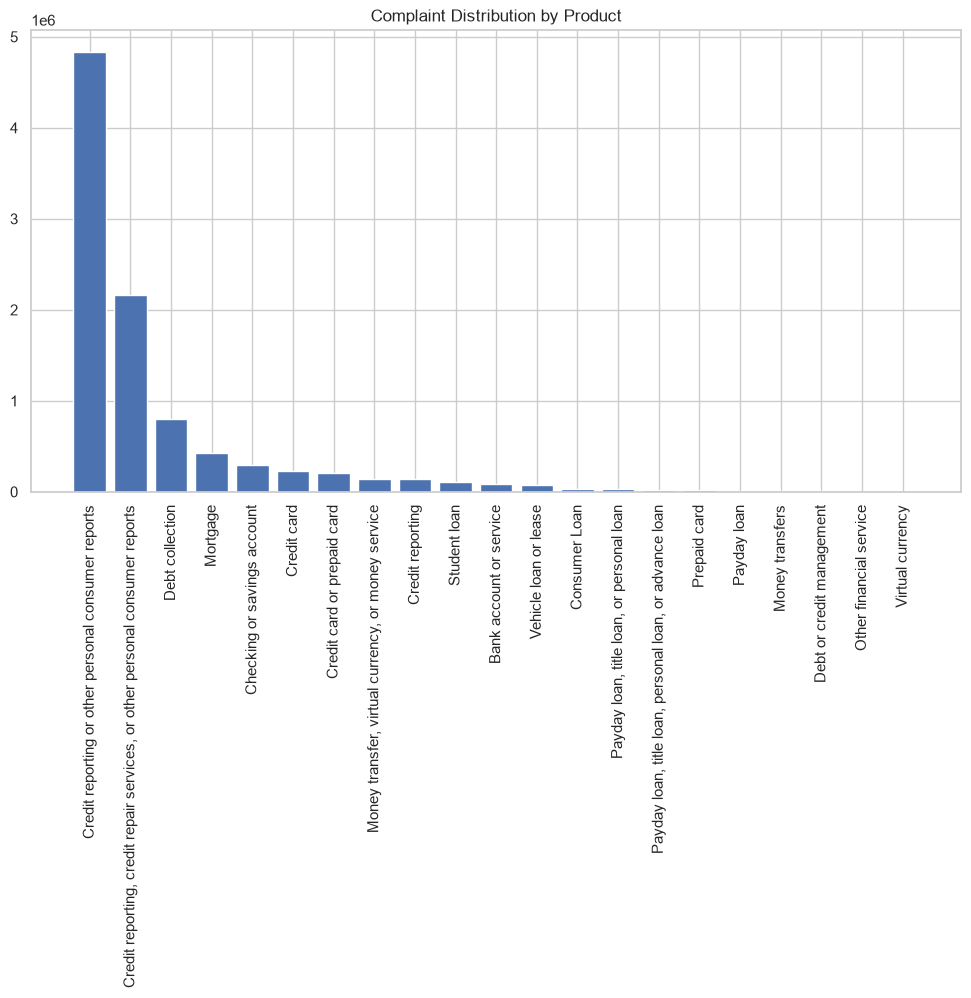

In [5]:


import matplotlib.pyplot as plt

product_dist_pd = product_dist.to_pandas()

plt.figure(figsize=(12,6))
plt.bar(
    product_dist_pd["Product"],
    product_dist_pd["len"]
)
plt.xticks(rotation=90)
plt.title("Complaint Distribution by Product")
plt.show()

#### Filter to the Four Required Product Families

In [12]:
selected_products = [
    "Credit card",
    "Checking or savings account",
    "Payday loan, title loan, personal loan, or advance loan",
    "Payday loan, title loan, or personal loan",
    "Money transfers",
    "Money transfer, virtual currency, or money service"
]

filtered_df = (
    df_raw.filter(
        pl.col("Product").is_in(selected_products)
    )
)

#### Map to the Four Required Product Families

In [13]:
product_mapping = {
    "Credit card": "Credit card",

    "Checking or savings account": "Checking/Savings Account",


    "Payday loan, title loan, personal loan, or advance loan":
        "Payday/Title/Personal Loan",

    "Payday loan, title loan, or personal loan":
        "Payday/Title/Personal Loan",

    "Money transfers":
        "Money Transfer",

    "Money transfer, virtual currency, or money service":
        "Money Transfer"
}

filtered_df = filtered_df.with_columns(
    pl.col("Product")
      .replace(product_mapping)
      .alias("Product_Family")
)

#### Then plot:

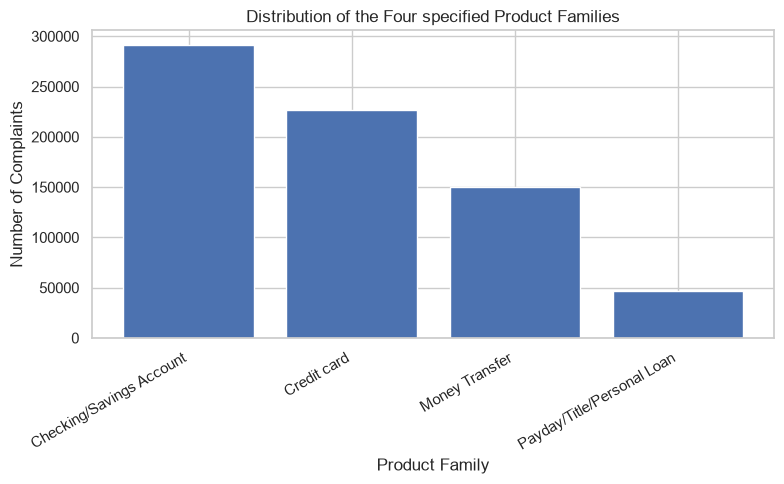

In [14]:
import matplotlib.pyplot as plt

family_counts = (
    filtered_df
    .group_by("Product_Family")
    .len()
    .sort("len", descending=True)
    .collect()
    .to_pandas()
)

plt.figure(figsize=(8, 5))
plt.bar(
    family_counts["Product_Family"].to_list(),
    family_counts["len"].to_list()
)

plt.title("Distribution of the Four specified Product Families")
plt.xlabel("Product Family")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

#### Distribution of the Four Product Families

The distribution of complaints across the four selected product families reveals a significant class imbalance within the dataset. The Checking/Savings Account category contains the largest number of complaints, with approximately 290,000 records, followed by Credit Card complaints at around 225,000 records. Money Transfer products account for approximately 150,000 complaints, while Payday/Title/Personal Loans represent the smallest category with roughly 45,000 complaints.

This distribution indicates that consumer complaints are concentrated primarily in traditional banking products, particularly checking and savings accounts. The high volume of complaints in these categories may reflect their widespread usage among consumers, as well as the frequency of issues related to account management, transactions, fees, and customer service.

The substantial difference in complaint counts between categories suggests that the dataset is not balanced. The largest category contains more than six times the number of complaints found in the Payday/Title/Personal Loan category. Such imbalance should be considered during the development and evaluation of the RAG Complaint Chatbot, as product families with larger datasets will naturally contribute more examples to the retrieval system.

From a Retrieval-Augmented Generation (RAG) perspective, the abundance of complaint narratives in the Checking/Savings Account and Credit Card categories is advantageous because it provides richer contextual information for embedding generation and document retrieval. However, additional care should be taken when evaluating chatbot performance on the Payday/Title/Personal Loan category, as the smaller number of examples may reduce retrieval diversity and potentially impact response quality.

Overall, the selected product families provide a broad representation of consumer financial complaints while highlighting the importance of monitoring retrieval performance across both high-volume and low-volume categories.
 

#### Complaints With and Without Narratives
-  Count complaints with and without narratives

In [15]:
narrative_counts = (
     df_raw.select(
        [
            pl.col("Consumer complaint narrative")
              .is_null()
              .sum()
              .alias("Without Narrative"),

            pl.col("Consumer complaint narrative")
              .is_not_null()
              .sum()
              .alias("With Narrative")
        ]
    )
    .collect()
)

print(narrative_counts)

shape: (1, 2)
┌───────────────────┬────────────────┐
│ Without Narrative ┆ With Narrative │
│ ---               ┆ ---            │
│ u32               ┆ u32            │
╞═══════════════════╪════════════════╡
│ 6629041           ┆ 2980756        │
└───────────────────┴────────────────┘


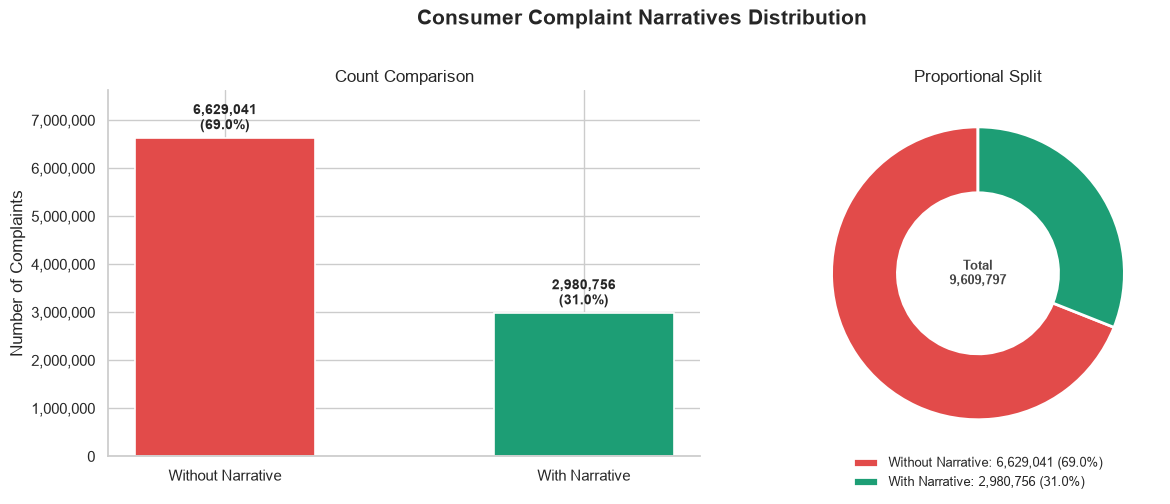

In [16]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Data from your result
labels = ["Without Narrative", "With Narrative"]
values = [6_629_041, 2_980_756]
total = sum(values)
percentages = [v / total * 100 for v in values]
colors = ["#E24B4A", "#1D9E75"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Consumer Complaint Narratives Distribution", fontsize=15, fontweight="bold", y=1.01)

# --- Bar Chart ---
bars = axes[0].bar(labels, values, color=colors, width=0.5, edgecolor="white", linewidth=1.2)
axes[0].set_title("Count Comparison", fontsize=12)
axes[0].set_ylabel("Number of Complaints")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[0].set_ylim(0, max(values) * 1.15)
for bar, val, pct in zip(bars, values, percentages):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100_000,
        f"{val:,}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )
axes[0].spines[["top", "right"]].set_visible(False)

# --- Donut Chart ---
wedge_props = {"width": 0.45, "edgecolor": "white", "linewidth": 2}
wedges, texts = axes[1].pie(
    values, colors=colors, startangle=90,
    wedgeprops=wedge_props
)
axes[1].set_title("Proportional Split", fontsize=12)
legend_labels = [f"{l}: {v:,} ({p:.1f}%)" for l, v, p in zip(labels, values, percentages)]
axes[1].legend(wedges, legend_labels, loc="lower center",
               bbox_to_anchor=(0.5, -0.12), fontsize=9, frameon=False)
axes[1].text(0, 0, f"Total\n{total:,}", ha="center", va="center",
             fontsize=9, fontweight="bold", color="#444")

plt.tight_layout()
plt.savefig("narrative_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### Consumer Complaint Narratives Distribution Interpretation
-  Majority of complaints lack narratives — nearly 7 in 10 complaints were submitted without any free-text explanation from the consumer.
-  Only ~31% include a narrative, meaning NLP-based analysis (sentiment, topic modeling, keyword extraction) can only be applied to about a third of the dataset.
-  Implication for modeling: if you plan to use the narrative text as a feature, you'll need a strategy to handle the ~6.6M missing values — either dropping them, imputing a placeholder (e.g. "No narrative"), or training separate models for each group.
-  Potential bias: complaints with narratives may skew toward more serious or complex cases, since consumers who write descriptions often have stronger grievances.

### Remove Empty Narratives
#### Remove records with empty consumer complaint narrative field


In [18]:
filtered_df = (
    filtered_df.filter(
        pl.col("Consumer complaint narrative")
        .is_not_null()
        &
        (pl.col("Consumer complaint narrative").str.len_chars() > 0)
    )
)

#### Narrative Length Analysis

In [19]:
narrative_lengths = (
    filtered_df.with_columns(
        pl.col("Consumer complaint narrative")
          .str.split(" ")
          .list.len()
          .alias("word_count")
    )
)

In [20]:
length_stats = (
    narrative_lengths
    .select(
        [
            pl.col("word_count").mean().alias("mean_words"),
            pl.col("word_count").median().alias("median_words"),
            pl.col("word_count").min().alias("min_words"),
            pl.col("word_count").max().alias("max_words")
        ]
    )
    .collect()
)

print(length_stats)

shape: (1, 4)
┌────────────┬──────────────┬───────────┬───────────┐
│ mean_words ┆ median_words ┆ min_words ┆ max_words │
│ ---        ┆ ---          ┆ ---       ┆ ---       │
│ f64        ┆ f64          ┆ u32       ┆ u32       │
╞════════════╪══════════════╪═══════════╪═══════════╡
│ 199.862503 ┆ 127.0        ┆ 1         ┆ 6617      │
└────────────┴──────────────┴───────────┴───────────┘


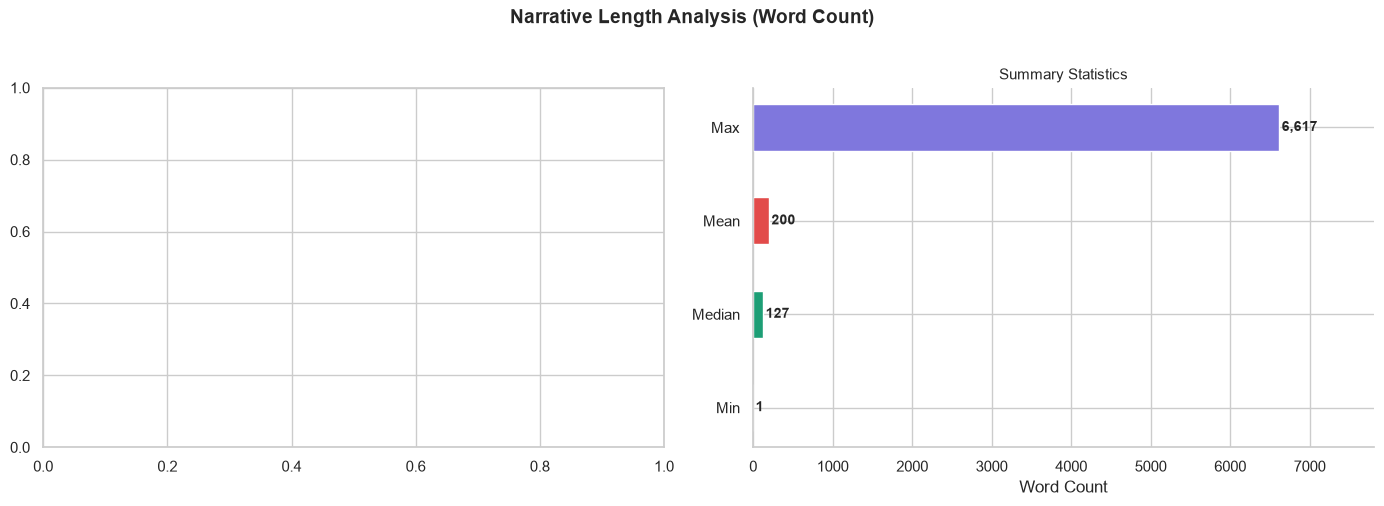

In [22]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Stats from your result
mean_words   = 199.86
median_words = 127.0
min_words    = 1
max_words    = 6617

# ── Sample word_count distribution for histogram (collect a sample) ──────────
# If you have narrative_lengths still in memory, use:
# sample = narrative_lengths.select("word_count").collect()["word_count"].to_numpy()
np.random.seed(42)
mu    = np.log(median_words)
sigma = 0.9
sample = np.random.lognormal(mu, sigma, size=50_000)
sample = np.clip(sample, min_words, max_words)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Narrative Length Analysis (Word Count)", fontsize=14, fontweight="bold", y=1.01)
# ── . Summary stats bar ──────────────────────────────────────────────────────
ax2 = axes[1]
stat_labels = ["Min", "Median", "Mean", "Max"]
stat_values = [min_words, median_words, mean_words, max_words]
bar_colors  = ["#73726c", "#1D9E75", "#E24B4A", "#7F77DD"]
bars = ax2.barh(stat_labels, stat_values, color=bar_colors, height=0.5, edgecolor="white")
ax2.set_title("Summary Statistics", fontsize=11)
ax2.set_xlabel("Word Count")
for bar, val in zip(bars, stat_values):
    ax2.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
             f"{val:,.0f}", va="center", fontsize=10, fontweight="bold")
ax2.set_xlim(0, max_words * 1.18)
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("narrative_length_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

#### What the numbers reveal
Strong right skew. The mean (199.9) is 57% higher than the median (127), which is a classic sign of a right-skewed distribution. This means most consumers write relatively short narratives, but a long tail of very detailed complaints pulls the average up significantly.
Typical narrative is brief. Half of all narratives contain 127 words or fewer — roughly 3–4 short paragraphs. This aligns with consumers describing a single incident concisely.
Extreme outliers exist. The maximum of 6,617 words is nearly 52× the median, suggesting some consumers submitted very lengthy accounts — possibly including copied correspondence, legal text, or repeated content.
Implications for NLP modeling:

Consider truncating at the 95th–99th percentile (likely around 500–800 words) before feeding into transformer models with token limits.
The skew means median is a more reliable central tendency than mean for reporting "typical" narrative length.
Very short narratives (< 10 words) may be low-signal — a filtering step at that threshold is worth considering.
A log transformation of word_count will produce a more normal distribution if used as a feature in regression or classification models.

### Clean Text

A strong cleaning pipeline for a RAG project:

In [23]:


cleaned_df = (
    filtered_df.with_columns(
        pl.col("Consumer complaint narrative")
        .str.to_lowercase()

        .str.replace_all(
            r"i am writing to file (a )?complaint",
            ""
        )

        .str.replace_all(
            r"[^a-z0-9\s]",
            " "
        )

        .str.replace_all(
            r"\s+",
            " "
        )

        .str.strip_chars()

        .alias("cleaned_narrative")
    )
)

#### Save for the RAG Pipeline

-  This is important after cleaning, it's recommended to save the processed data for further text chunking, embedding, and vector store indexing

In [24]:
final_df = cleaned_df.collect()

In [25]:
# Save as Parquet:

final_df.write_parquet(
    "../data/processed/filtered_complaints.parquet"
)

In [26]:
# CSV:

final_df.write_csv(
    "../data/processed/filtered_complaints.csv"
)
print("Filtered Data saved succssefully")
             

Filtered Data saved succssefully
